# Evaluacion del modelo de churn (5 meses)

Cambios respecto a la version anterior:

- Target ampliado: churn = duracion <= 5 meses (antes <= 3)
- Features solo de meses 1 y 2 (month3 ya cae en la ventana de churn)
- Ratios de conversion y normalizados por precio
- Sin class weighting (29% churn, no hace falta)
- Excluidas `n_months_post_onboarding`, `stable_price_*`, `invoice_post_*` por leakage

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, classification_report,
    RocCurveDisplay, ConfusionMatrixDisplay,
)
from sklearn.inspection import permutation_importance, partial_dependence

import warnings
warnings.filterwarnings("ignore")

## 1. Datos

In [2]:
df = pd.read_parquet("../data/df_5m_churn.parquet")
target = "churned_5m"

print(f"Dataset: {df.shape[0]} contratos, {df.shape[1]} columnas")
print(f"Churn rate: {df[target].mean():.1%} ({int(df[target].sum())} contratos)")

Dataset: 3599 contratos, 127 columnas
Churn rate: 28.9% (1039 contratos)


## 2. Seleccion de features

Excluimos identificadores, metadata, flags de missing y variables con leakage (`n_months_post_onboarding` es proxy directo de la duracion, `stable_price_*` e `invoice_post_*` usan datos post-onboarding).

In [3]:
meta_cols = [
    "advertiser_zrive_id", "contract_id", "period_int",
    "contract_start_date", "contract_end_period", "contrato_churn_date",
    "contract_duration_months", "advertiser_group_id", "advertiser_province",
    "is_right_censored", "right_censoring_case", "province_id",
]
leakage_cols = [
    "n_months_post_onboarding",
    "stable_price_mean", "stable_price_median", "stable_price_std",
]
exclude = set(meta_cols + leakage_cols + [target])
feature_cols = [
    c for c in df.columns
    if c not in exclude
    and not c.endswith("_was_missing")
    and not c.startswith("invoice_post_")
]
print(f"{len(feature_cols)} features")

83 features


## 3. Split por advertiser

In [4]:
X = df[feature_cols].fillna(0)
y = df[target].astype(int)
groups = df["advertiser_zrive_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train: {len(X_train)} ({y_train.mean():.1%} churn)")
print(f"Test:  {len(X_test)} ({y_test.mean():.1%} churn)")
print(f"Overlap advertisers: {len(set(groups.iloc[train_idx]) & set(groups.iloc[test_idx]))}")

Train: 2874 (29.0% churn)
Test:  725 (28.3% churn)
Overlap advertisers: 0


## 4. Comparativa de modelos

In [5]:
models = {
    "Baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(max_iter=1000, C=0.1, random_state=42)),
    ]),
    "Random Forest": RandomForestClassifier(n_estimators=20, random_state=42, n_jobs=-1),
    "Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=200, max_depth=5, learning_rate=0.1, random_state=42,
    ),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    tr = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
    te = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    pr = average_precision_score(y_test, model.predict_proba(X_test)[:, 1])
    results.append({"name": name, "train_auc": tr, "test_auc": te, "pr_auc": pr})

print(f"{'Modelo':<25} {'Train':>7} {'Test':>7} {'Gap':>7} {'PR-AUC':>8}")
print("-" * 58)
for r in results:
    print(f"{r['name']:<25} {r['train_auc']:>7.3f} {r['test_auc']:>7.3f} {r['train_auc']-r['test_auc']:>+7.3f} {r['pr_auc']:>8.3f}")

Modelo                      Train    Test     Gap   PR-AUC
----------------------------------------------------------
Baseline                    0.500   0.500  +0.000    0.283
Logistic Regression         0.687   0.678  +0.010    0.436
Random Forest               0.999   0.676  +0.323    0.435
Gradient Boosting           0.997   0.676  +0.321    0.456


## 5. Feature importance y seleccion

Ranking completo con todas las features, y luego nos quedamos con las top 20.

In [6]:
gb_full = HistGradientBoostingClassifier(
    max_iter=200, max_depth=5, learning_rate=0.1, random_state=42,
)
gb_full.fit(X_train, y_train)

perm_imp = permutation_importance(
    gb_full, X_test, y_test,
    n_repeats=10, random_state=42, scoring="roc_auc",
)
feat_ranking = pd.Series(perm_imp.importances_mean, index=feature_cols).sort_values(ascending=False)

top20 = list(feat_ranking.head(20).index)
print("Top 20 features:")
for i, (feat, imp) in enumerate(feat_ranking.head(20).items(), 1):
    print(f"  {i:>2}. {feat:<40} {imp:.4f}")

Top 20 features:
   1. has_group                                0.0252
   2. monthly_published_ads_month2             0.0212
   3. monthly_distinct_ads_month1              0.0177
   4. usage_ratio                              0.0121
   5. monthly_total_invoice                    0.0119
   6. monthly_total_invoice_trend              0.0085
   7. contracted_ads_per_price                 0.0064
   8. unique_leads_ratio                       0.0061
   9. monthly_shows_month1                     0.0058
  10. shows_per_price                          0.0045
  11. monthly_shows_std                        0.0041
  12. phone_views_per_visit                    0.0038
  13. calls_per_lead                           0.0037
  14. emails_per_visit                         0.0036
  15. monthly_total_phone_views_month1         0.0034
  16. monthly_total_calls_month1               0.0030
  17. monthly_leads_month2                     0.0024
  18. monthly_avg_ad_price_month1              0.0024
  19. month

## 6. Reduccion de overfitting

Combinamos feature selection (top 20), depth=2 y learning rate bajo (0.01).

In [7]:
gkf = GroupKFold(n_splits=5)

configs = {
    "84 feat, d=5, lr=0.1": (feature_cols, 5, 0.1, 200),
    "Top 20, d=5, lr=0.1": (top20, 5, 0.1, 200),
    "Top 20, d=3, lr=0.01": (top20, 3, 0.01, 1000),
    "Top 20, d=2, lr=0.01": (top20, 2, 0.01, 1000),
}

print(f"{'Config':<30} {'Train':>7} {'Test':>7} {'Gap':>7} {'CV AUC':>14}")
print("-" * 70)
for label, (cols, depth, lr, iters) in configs.items():
    Xc = df[cols].fillna(0)
    Xc_tr, Xc_te = Xc.iloc[train_idx], Xc.iloc[test_idx]

    gb = HistGradientBoostingClassifier(
        max_iter=iters, max_depth=depth, learning_rate=lr, random_state=42,
    )
    gb.fit(Xc_tr, y_train)
    tr = roc_auc_score(y_train, gb.predict_proba(Xc_tr)[:, 1])
    te = roc_auc_score(y_test, gb.predict_proba(Xc_te)[:, 1])

    cv = cross_val_score(
        HistGradientBoostingClassifier(max_iter=iters, max_depth=depth, learning_rate=lr, random_state=42),
        Xc_tr, y_train, cv=gkf, groups=groups.iloc[train_idx], scoring="roc_auc", n_jobs=-1,
    )
    print(f"{label:<30} {tr:>7.3f} {te:>7.3f} {tr-te:>+7.3f} {cv.mean():.3f}±{cv.std():.3f}")

Config                           Train    Test     Gap         CV AUC
----------------------------------------------------------------------


84 feat, d=5, lr=0.1             0.997   0.676  +0.321 0.684±0.023


Top 20, d=5, lr=0.1              0.990   0.709  +0.281 0.659±0.018


Top 20, d=3, lr=0.01             0.837   0.717  +0.120 0.677±0.014


Top 20, d=2, lr=0.01             0.773   0.711  +0.062 0.678±0.020


## 7. Modelo final: GB top 20, depth=2, lr=0.01

In [8]:
X_train_sel = df[top20].fillna(0).iloc[train_idx]
X_test_sel = df[top20].fillna(0).iloc[test_idx]

gb_final = HistGradientBoostingClassifier(
    max_iter=1000, max_depth=2, learning_rate=0.01, random_state=42,
)
gb_final.fit(X_train_sel, y_train)

y_proba = gb_final.predict_proba(X_test_sel)[:, 1]

print(f"Train AUC: {roc_auc_score(y_train, gb_final.predict_proba(X_train_sel)[:, 1]):.3f}")
print(f"Test AUC:  {roc_auc_score(y_test, y_proba):.3f}")
print(f"PR-AUC:    {average_precision_score(y_test, y_proba):.3f}")

Train AUC: 0.773
Test AUC:  0.711
PR-AUC:    0.491


## 8. Cross-validation

In [9]:
roc_cv = cross_val_score(
    HistGradientBoostingClassifier(max_iter=1000, max_depth=2, learning_rate=0.01, random_state=42),
    X_train_sel, y_train, cv=gkf, groups=groups.iloc[train_idx],
    scoring="roc_auc", n_jobs=-1,
)
pr_cv = cross_val_score(
    HistGradientBoostingClassifier(max_iter=1000, max_depth=2, learning_rate=0.01, random_state=42),
    X_train_sel, y_train, cv=gkf, groups=groups.iloc[train_idx],
    scoring="average_precision", n_jobs=-1,
)
print(f"ROC AUC (CV): {roc_cv.mean():.3f} ± {roc_cv.std():.3f}")
print(f"PR AUC (CV):  {pr_cv.mean():.3f} ± {pr_cv.std():.3f}")
print(f"Folds: {[f'{s:.3f}' for s in roc_cv]}")

ROC AUC (CV): 0.678 ± 0.020
PR AUC (CV):  0.445 ± 0.036
Folds: ['0.649', '0.679', '0.676', '0.674', '0.713']


## 9. Curvas ROC y Precision-Recall

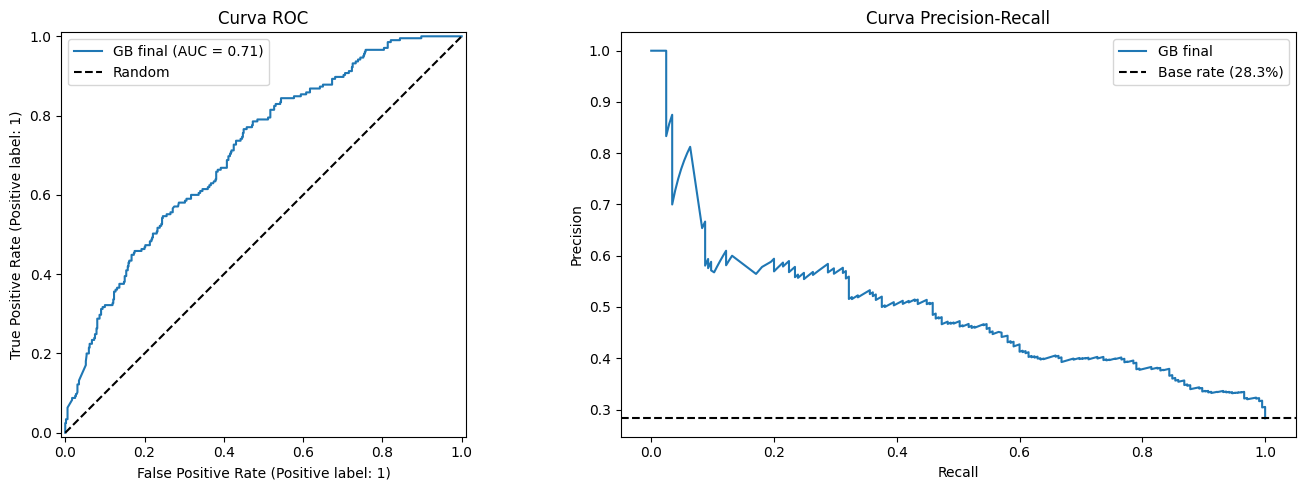

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(y_test, y_proba, name="GB final", ax=axes[0])
axes[0].plot([0, 1], [0, 1], "k--", label="Random")
axes[0].set_title("Curva ROC")
axes[0].legend()

precs, recs, _ = precision_recall_curve(y_test, y_proba)
axes[1].plot(recs, precs, label="GB final")
axes[1].axhline(y=y_test.mean(), color="k", linestyle="--", label=f"Base rate ({y_test.mean():.1%})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Curva Precision-Recall")
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Feature importance (modelo final)

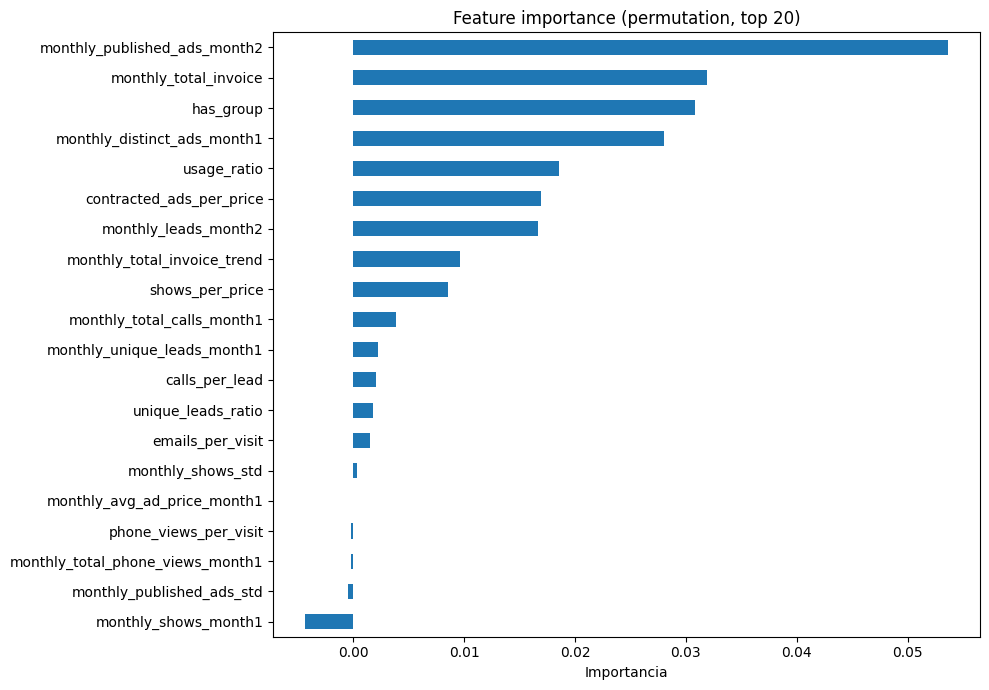

In [11]:
perm_final = permutation_importance(
    gb_final, X_test_sel, y_test,
    n_repeats=10, random_state=42, scoring="roc_auc",
)
imp_series = pd.Series(perm_final.importances_mean, index=top20).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
imp_series.plot(kind="barh", ax=ax)
ax.set_title("Feature importance (permutation, top 20)")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.show()

## 11. Threshold optimo

In [12]:
precs_t, recs_t, threshs_t = precision_recall_curve(y_test, y_proba)
f1s = 2 * (precs_t * recs_t) / (precs_t + recs_t + 1e-8)
best_idx = np.argmax(f1s)
best_thresh = threshs_t[best_idx] if best_idx < len(threshs_t) else 1.0

print(f"Threshold: {best_thresh:.3f}")
print(f"Precision: {precs_t[best_idx]:.3f}, Recall: {recs_t[best_idx]:.3f}, F1: {f1s[best_idx]:.3f}")

y_pred_opt = (y_proba >= best_thresh).astype(int)
print(f"\n{classification_report(y_test, y_pred_opt, target_names=['No churn', 'Churn'])}")

Threshold: 0.293
Precision: 0.402, Recall: 0.766, F1: 0.527

              precision    recall  f1-score   support

    No churn       0.86      0.55      0.67       520
       Churn       0.40      0.77      0.53       205

    accuracy                           0.61       725
   macro avg       0.63      0.66      0.60       725
weighted avg       0.73      0.61      0.63       725



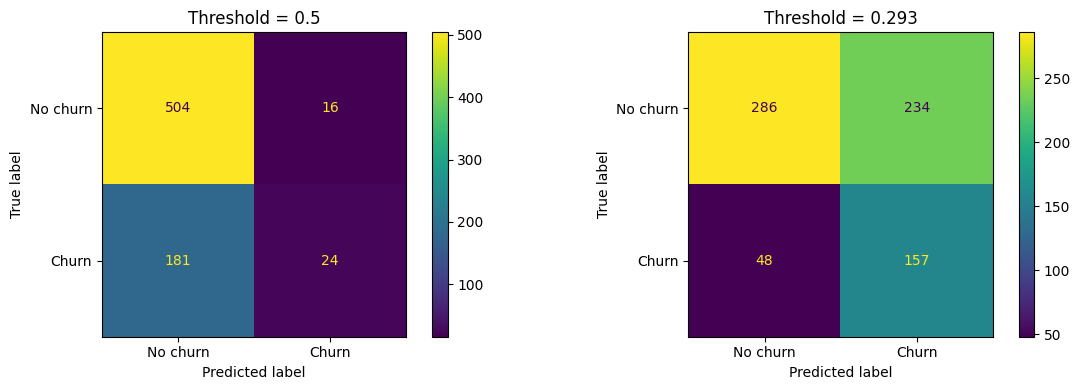

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, (y_proba >= 0.5).astype(int),
    display_labels=["No churn", "Churn"], ax=axes[0],
)
axes[0].set_title("Threshold = 0.5")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_opt,
    display_labels=["No churn", "Churn"], ax=axes[1],
)
axes[1].set_title(f"Threshold = {best_thresh:.3f}")

plt.tight_layout()
plt.show()

## 12. Perfiles de riesgo

In [14]:
df_test = X_test_sel.copy()
df_test["churn_proba"] = y_proba
df_test["churned"] = y_test.values
df_test["riesgo"] = pd.cut(df_test["churn_proba"], bins=[0, 0.15, 0.4, 1.0], labels=["Bajo", "Medio", "Alto"])

profiles = []
for riesgo in ["Bajo", "Medio", "Alto"]:
    mask = df_test["riesgo"] == riesgo
    n = int(mask.sum())
    if n > 0:
        profiles.append({
            "Riesgo": riesgo, "N": n,
            "Churn real": f"{df_test.loc[mask, 'churned'].mean():.1%}",
            "Proba media": f"{df_test.loc[mask, 'churn_proba'].mean():.3f}",
        })
pd.DataFrame(profiles)

,Riesgo,N,Churn real,Proba media
0,Bajo,128,5.5%,0.072
1,Medio,467,28.1%,0.294
2,Alto,130,51.5%,0.481


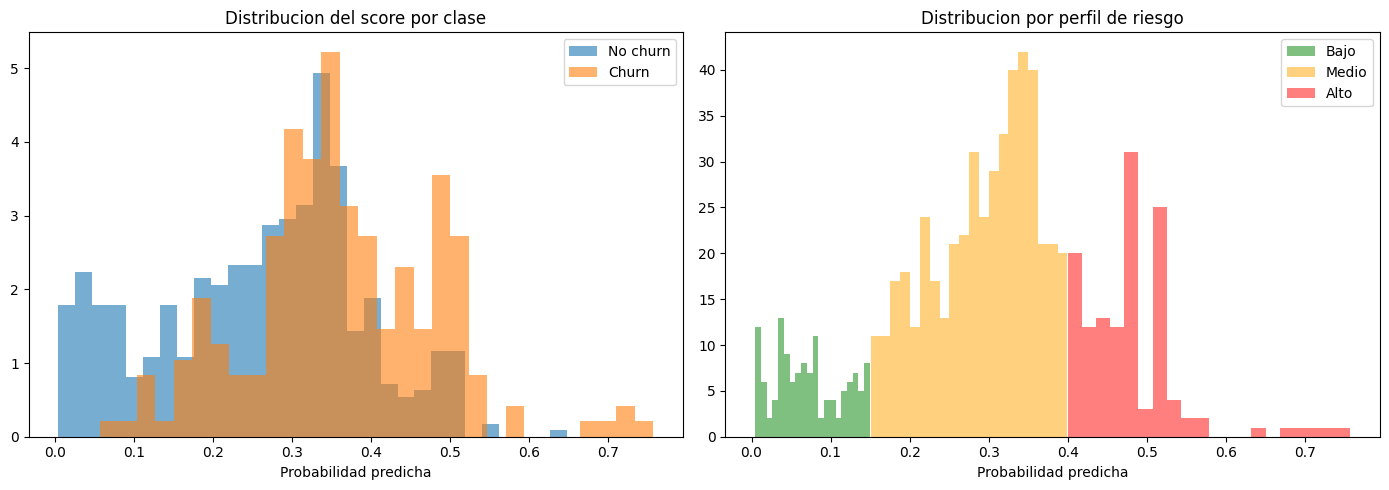

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_proba[y_test == 0], bins=30, alpha=0.6, label="No churn", density=True)
axes[0].hist(y_proba[y_test == 1], bins=30, alpha=0.6, label="Churn", density=True)
axes[0].set_xlabel("Probabilidad predicha")
axes[0].set_title("Distribucion del score por clase")
axes[0].legend()

for riesgo, color in [("Bajo", "green"), ("Medio", "orange"), ("Alto", "red")]:
    mask = df_test["riesgo"] == riesgo
    if mask.sum() > 0:
        axes[1].hist(df_test.loc[mask, "churn_proba"], bins=20, alpha=0.5, label=riesgo, color=color)
axes[1].set_xlabel("Probabilidad predicha")
axes[1].set_title("Distribucion por perfil de riesgo")
axes[1].legend()

plt.tight_layout()
plt.show()

## 13. Metrica de negocio

In [16]:
sorted_idx = np.argsort(-y_proba)
total_churns = y_test.sum()

rows = []
for k in [5, 10, 20, 30]:
    n_int = int(len(y_test) * k / 100)
    top_idx = sorted_idx[:n_int]
    tp = y_test.iloc[top_idx].sum()
    rows.append({"Top %": f"{k}%", "N": n_int, "Churns": int(tp),
                 "Precision": f"{tp/n_int:.1%}", "Recall": f"{tp/total_churns:.1%}"})
pd.DataFrame(rows)

,Top %,N,Churns,Precision,Recall
0,5%,36,21,58.3%,10.2%
1,10%,72,41,56.9%,20.0%
2,20%,145,75,51.7%,36.6%
3,30%,217,102,47.0%,49.8%


## 14. Analisis de precio y churn

Relacion entre precio/facturacion y churn por quintiles.

In [17]:
df_full = df.copy()
df_full["churn_proba"] = gb_final.predict_proba(df[top20].fillna(0))[:, 1]
df_full["churned"] = y.values

df_full["precio_bucket"] = pd.qcut(df_full["monthly_avg_ad_price"].clip(lower=0.01), q=5, duplicates="drop")
df_full["invoice_bucket"] = pd.qcut(df_full["monthly_total_invoice"].clip(lower=0.01), q=5, duplicates="drop")

print("Churn por quintil de precio (monthly_avg_ad_price):\n")
for bucket in sorted(df_full["precio_bucket"].dropna().unique()):
    mask = df_full["precio_bucket"] == bucket
    n = mask.sum()
    cr = df_full.loc[mask, "churned"].mean()
    cp = df_full.loc[mask, "churn_proba"].mean()
    pm = df_full.loc[mask, "monthly_avg_ad_price"].mean()
    print(f"  {str(bucket):<30} N={n:>4}  precio={pm:>8.0f}  churn_real={cr:.1%}  churn_pred={cp:.1%}")

print("\nChurn por quintil de facturacion (monthly_total_invoice):\n")
for bucket in sorted(df_full["invoice_bucket"].dropna().unique()):
    mask = df_full["invoice_bucket"] == bucket
    n = mask.sum()
    cr = df_full.loc[mask, "churned"].mean()
    cp = df_full.loc[mask, "churn_proba"].mean()
    im = df_full.loc[mask, "monthly_total_invoice"].mean()
    print(f"  {str(bucket):<30} N={n:>4}  invoice={im:>8.0f}  churn_real={cr:.1%}  churn_pred={cp:.1%}")

Churn por quintil de precio (monthly_avg_ad_price):

  (0.999, 9991.67]               N= 646  precio=    6773  churn_real=38.9%  churn_pred=36.4%
  (9991.67, 15999.0]             N= 645  precio=   13017  churn_real=30.7%  churn_pred=31.1%
  (15999.0, 20354.75]            N= 647  precio=   18321  churn_real=19.8%  churn_pred=21.4%
  (20354.75, 26968.68]           N= 643  precio=   23168  churn_real=22.2%  churn_pred=23.5%
  (26968.68, 802325.0]           N= 645  precio=   54665  churn_real=27.6%  churn_pred=27.0%

Churn por quintil de facturacion (monthly_total_invoice):

  (0.009000000000000001, 16.7]   N= 725  invoice=       3  churn_real=35.6%  churn_pred=34.3%
  (16.7, 70.0]                   N= 734  invoice=      50  churn_real=34.3%  churn_pred=34.9%
  (70.0, 122.5]                  N= 701  invoice=      94  churn_real=34.4%  churn_pred=33.8%
  (122.5, 235.12]                N= 719  invoice=     167  churn_real=26.3%  churn_pred=27.3%
  (235.12, 10194.9]              N= 720  invoi

## 15. Partial dependence de features de precio

Efecto marginal de cada feature de precio segun el modelo.

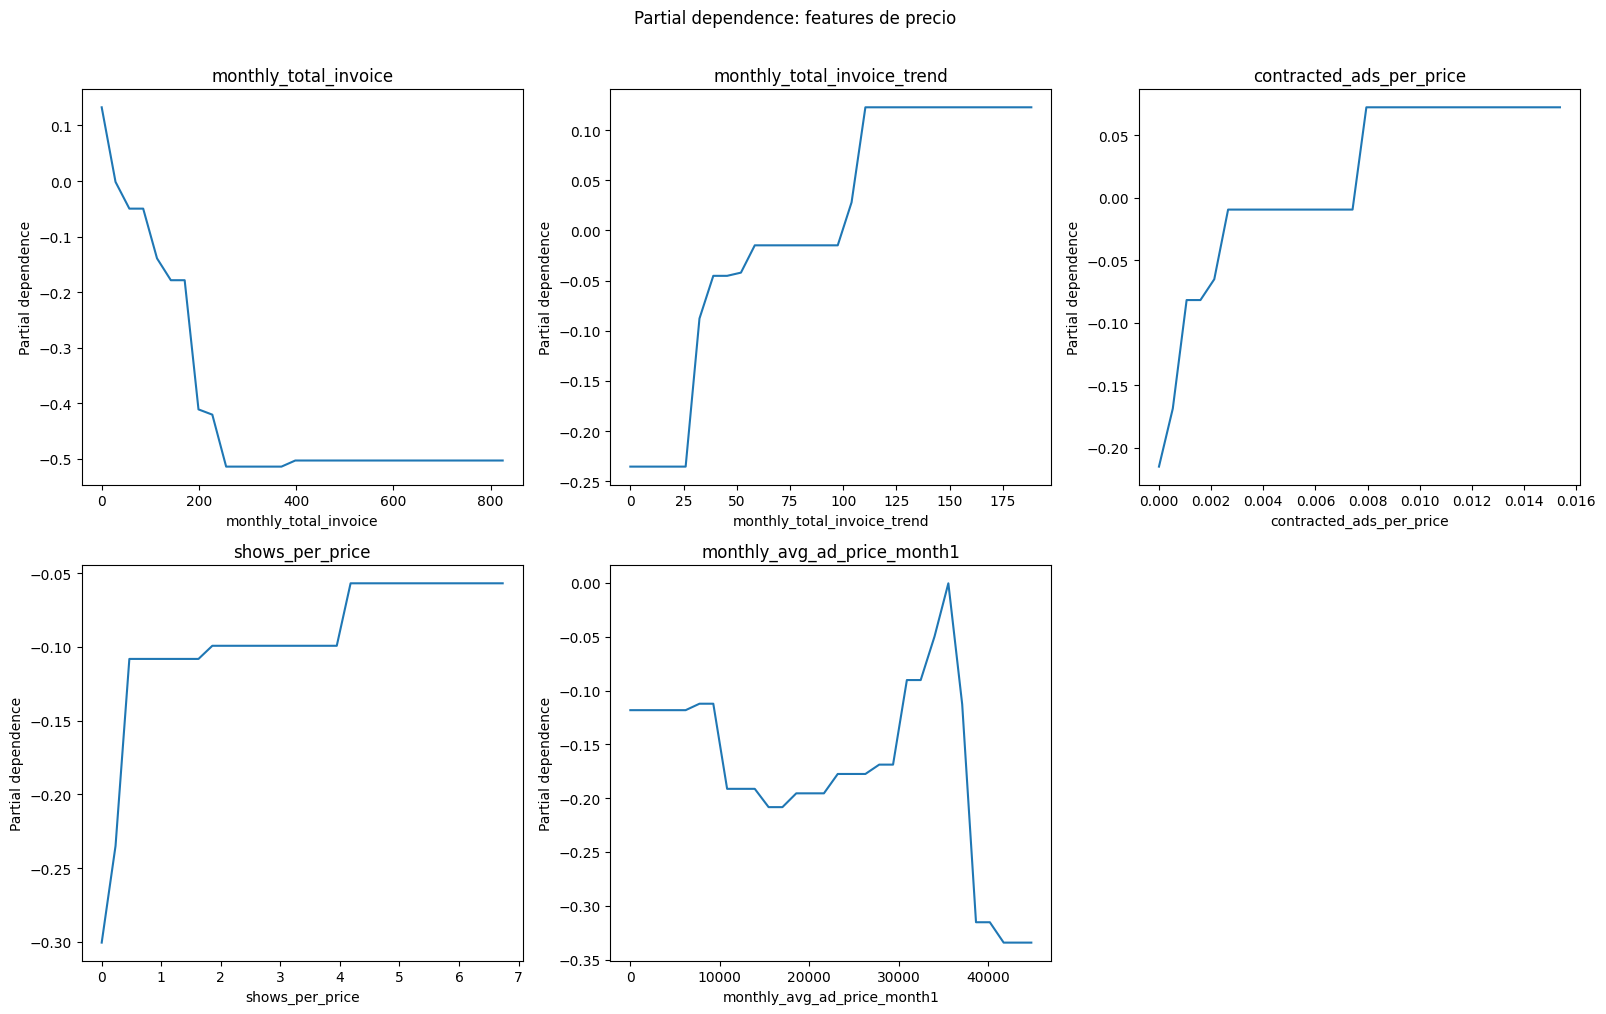

In [18]:
price_feats = [f for f in top20 if "price" in f or "invoice" in f]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(price_feats):
    feat_idx = top20.index(feat)
    result = partial_dependence(gb_final, X_train_sel, features=[feat_idx], kind="average", grid_resolution=30)
    axes[i].plot(result["grid_values"][0], result["average"][0])
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("Partial dependence")
    axes[i].set_title(feat)

for j in range(len(price_feats), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Partial dependence: features de precio", y=1.01)
plt.tight_layout()
plt.show()

## 16. Simulacion: efecto de subir/bajar precio

Que pasa con la prediccion de churn si escalamos las features de precio un 20% arriba y abajo.

In [19]:
proba_orig = gb_final.predict_proba(X_test_sel)[:, 1]

# +20% precio
X_up = X_test_sel.copy()
for col in ["monthly_total_invoice", "monthly_total_invoice_month1", "monthly_total_invoice_trend"]:
    if col in X_up.columns:
        X_up[col] = X_up[col] * 1.2
for col in ["contracted_ads_per_price", "shows_per_price"]:
    if col in X_up.columns:
        X_up[col] = X_up[col] / 1.2
proba_up = gb_final.predict_proba(X_up)[:, 1]

# -20% precio
X_down = X_test_sel.copy()
for col in ["monthly_total_invoice", "monthly_total_invoice_month1", "monthly_total_invoice_trend"]:
    if col in X_down.columns:
        X_down[col] = X_down[col] * 0.8
for col in ["contracted_ads_per_price", "shows_per_price"]:
    if col in X_down.columns:
        X_down[col] = X_down[col] / 0.8
proba_down = gb_final.predict_proba(X_down)[:, 1]

print(f"Proba media original:      {proba_orig.mean():.4f}")
print(f"Proba media (+20% precio): {proba_up.mean():.4f} ({proba_up.mean()-proba_orig.mean():+.4f})")
print(f"Proba media (-20% precio): {proba_down.mean():.4f} ({proba_down.mean()-proba_orig.mean():+.4f})")

print("\nPor segmento de riesgo:")
for label, lo, hi in [("Bajo", 0, 0.15), ("Medio", 0.15, 0.4), ("Alto", 0.4, 1.0)]:
    mask = (proba_orig >= lo) & (proba_orig < hi)
    if mask.sum() > 0:
        o = proba_orig[mask].mean()
        u = proba_up[mask].mean()
        d = proba_down[mask].mean()
        print(f"  {label:<6}  orig={o:.3f}  +20%={u:.3f} ({u-o:+.3f})  -20%={d:.3f} ({d-o:+.3f})")

Proba media original:      0.2882
Proba media (+20% precio): 0.2837 (-0.0044)
Proba media (-20% precio): 0.2930 (+0.0048)

Por segmento de riesgo:
  Bajo    orig=0.072  +20%=0.072 (-0.001)  -20%=0.079 (+0.007)
  Medio   orig=0.294  +20%=0.289 (-0.005)  -20%=0.302 (+0.008)
  Alto    orig=0.481  +20%=0.475 (-0.006)  -20%=0.471 (-0.010)


## 17. Comparativa con modelo anterior (churned_3m)

| | Anterior (3m) | Actual (5m) |
|---|---|---|
| Churn rate | 6.2% | 28.9% |
| CV ROC AUC | ~0.77 | ~0.69 |
| CV PR AUC | ~0.21 | ~0.46 |
| Gap (overfitting) | +0.15 | +0.06 |
| Features | 3 meses | 2 meses |

ROC AUC baja porque usamos menos datos y predecimos mas lejos. PR-AUC sube porque hay mas positivos.

## Conclusiones

- El target a 5 meses es mas realista y elimina el desbalanceo (6% -> 29%).
- Solo features de meses 1-2, sin leakage.
- Con top 20 features, depth=2 y lr=0.01 el gap queda en +0.06.
- `has_group`, anuncios publicados, invoice y usage_ratio son las mas importantes.
- `contracted_ads_per_price` (anuncios por euro) entra como top feature de precio.
- La relacion precio-churn no es causal: los que pagan mas usan mas y se quedan. Subir precio no reduce churn.